In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
from esem import rf_model
from eofs.xarray import Eof
import itertools
import joblib  # Efficient for saving large models
from sklearn.metrics import mean_squared_error
from utils import *


2025-02-13 18:44:36.600837: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-13 18:44:36.782423: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739497476.848105    9498 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739497476.867411    9498 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-13 18:44:37.007557: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
train_files= ['ssp126', 'ssp585', 'picontrol']

In [3]:
NEOFS = 7 # for testing

Xtrain, eof_solvers, mean, std = get_Xtrain(train_files, NEOFS)

Ytrain = get_Ytrain(train_files)
Ytrain_yield = Ytrain['mai'].values.reshape(-1, 360*720)

Xtest = get_Xtest('ssp370', eof_solvers, mean, std)

Ytest = get_Ytest('ssp370')
yield_truth = Ytest['mai']

In [8]:
# Save the EOF solvers into a .pkl file
eof_solvers_path = "saved_models/eof_solvers.pkl"
joblib.dump(eof_solvers, eof_solvers_path)
print(f"EOF solvers saved successfully: {eof_solvers_path}")

EOF solvers saved successfully: saved_models/eof_solvers.pkl


### EDA For Crops


Processing region: United States


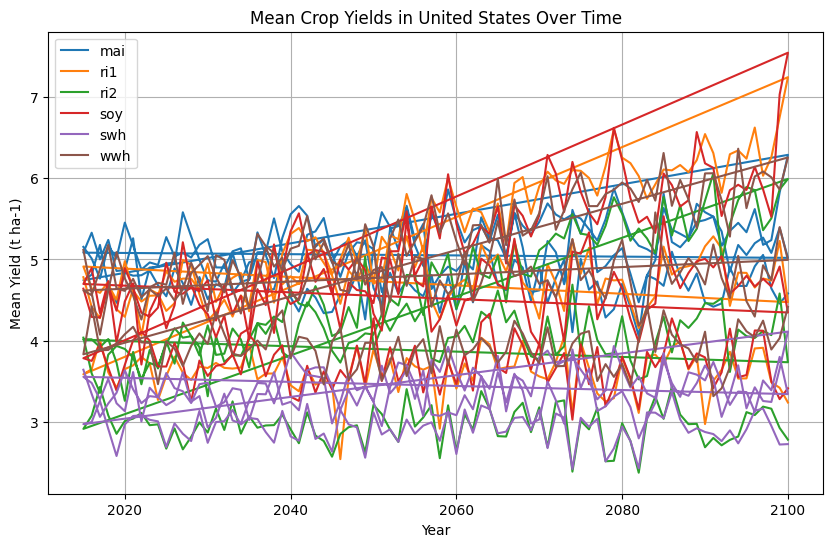


Processing region: Europe


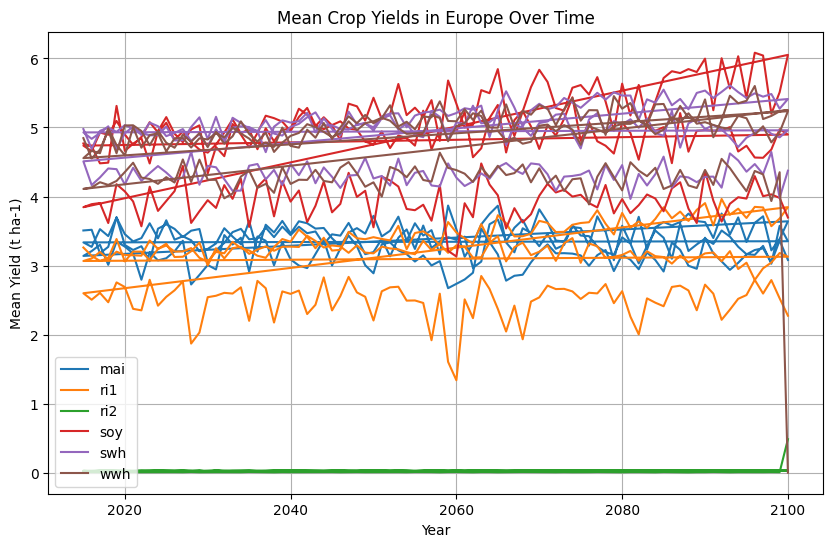


Processing region: Asia


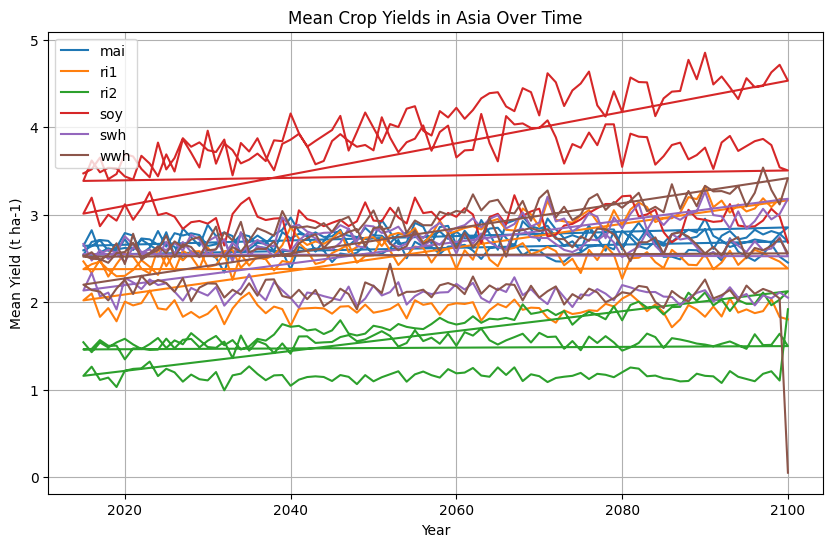


Processing region: Africa


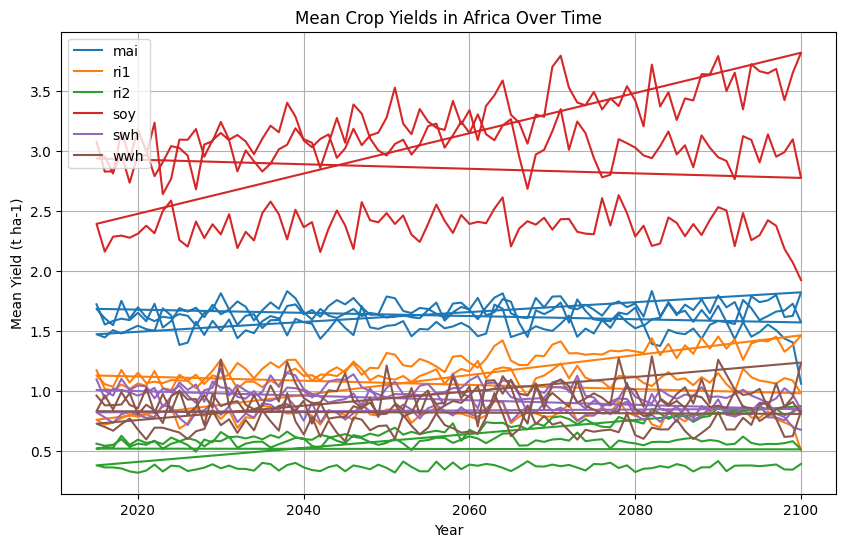

In [174]:
regions = {
    "United States": {"lat": slice(24, 49), "lon": slice(-125, -66)},
    "Europe": {"lat": slice(35, 71), "lon": slice(-25, 40)},  # Western Europe to Eastern Europe
    "Asia": {"lat": slice(5, 55), "lon": slice(60, 150)},  # Middle East to East Asia
    "Africa": {"lat": slice(-35, 37), "lon": slice(-20, 55)},  # Entire African continent
}

Ytrain = get_Ytrain(train_files)  # Load dataset

# Loop over each region
for region, coords in regions.items():
    print(f"\nProcessing region: {region}")

    # Select the region using `.where()` for flexibility
    lat_mask = (Ytrain.lat >= coords["lat"].start) & (Ytrain.lat <= coords["lat"].stop)
    lon_mask = (Ytrain.lon >= coords["lon"].start) & (Ytrain.lon <= coords["lon"].stop)
    Ytrain_region = Ytrain.where(lat_mask & lon_mask, drop=True)

    # Check if the region contains any data
    if Ytrain_region.to_array().isnull().all():
        print(f" Warning: No valid data available for {region}. Skipping plot.")
        continue  # Skip to the next region

    # Compute mean crop yields over lat/lon, handling NaNs
    region_crop_means = Ytrain_region.mean(dim=["lat", "lon"], skipna=True)

    # Plot mean crop yields over time
    plt.figure(figsize=(10, 6))
    for crop in region_crop_means.data_vars:
        if not region_crop_means[crop].isnull().all():  # Avoid plotting empty series
            plt.plot(region_crop_means.time, region_crop_means[crop], label=crop)

    plt.xlabel("Year")
    plt.ylabel("Mean Yield (t ha-1)")
    plt.title(f"Mean Crop Yields in {region} Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()

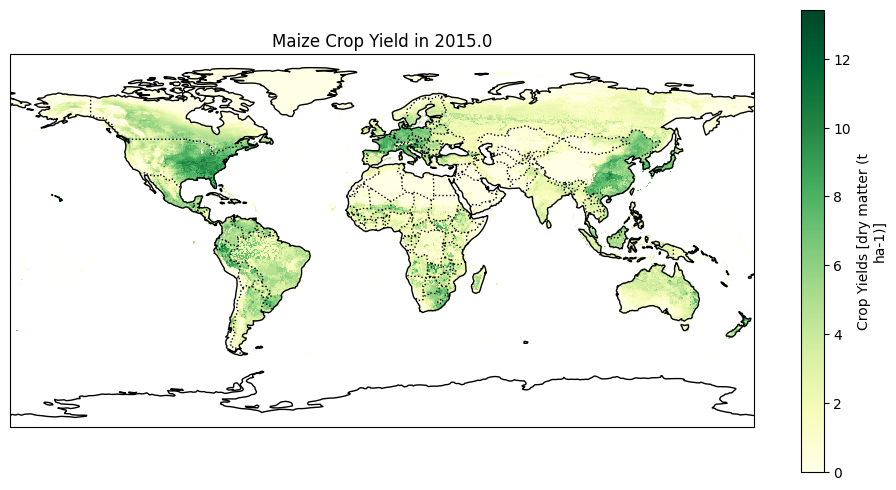

In [175]:
import cartopy.feature as cfeature

year_to_plot = get_Ytrain(train_files)['mai'].sel(time=2015).isel(time=0) 

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
year_to_plot.plot(ax=ax, cmap="YlGn")  

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

plt.title(f"Maize Crop Yield in {year_to_plot.time.values}")
plt.show()

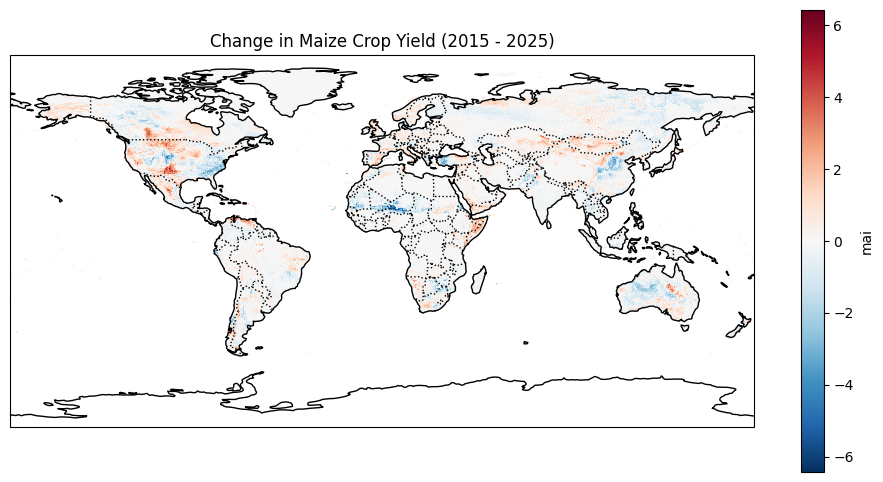

In [176]:
# Load crop yield data for 2015 and 2025
yields_2015 = get_Ytrain(train_files)['mai'].sel(time=2015).isel(time=0)
yields_2025 = get_Ytrain(train_files)['mai'].sel(time=2025).isel(time=0)

# Compute the difference (Change in Yield: 2025 - 2015)
yield_change = yields_2025 - yields_2015

# Plot the difference map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Use a diverging colormap to highlight increases and decreases
cbar = yield_change.plot(ax=ax, cmap="RdBu_r", transform=ccrs.PlateCarree())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add title and colorbar
plt.title("Change in Maize Crop Yield (2015 - 2025)")

# Show the plot
plt.show()

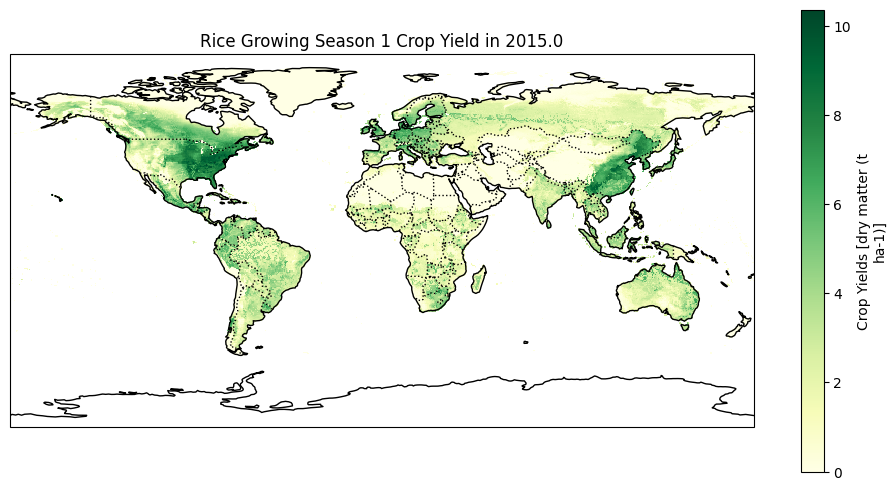

In [177]:
year_to_plot = get_Ytrain(train_files)['ri1'].sel(time=2015).isel(time=0) 

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
year_to_plot.plot(ax=ax, cmap="YlGn")  

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

plt.title(f"Rice Growing Season 1 Crop Yield in {year_to_plot.time.values}")
plt.show()

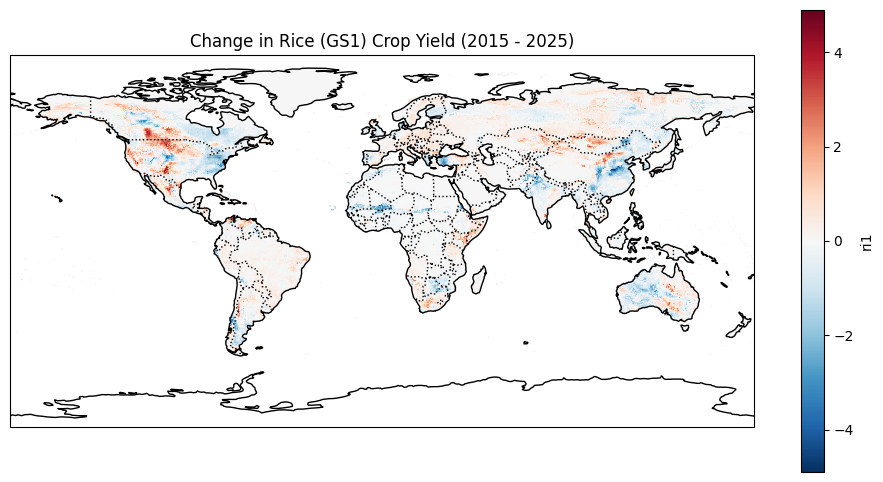

In [178]:
yields_2015 = get_Ytrain(train_files)['ri1'].sel(time=2015).isel(time=0)
yields_2025 = get_Ytrain(train_files)['ri1'].sel(time=2025).isel(time=0)

# Compute the difference (Change in Yield: 2025 - 2015)
yield_change = yields_2025 - yields_2015

# Plot the difference map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Use a diverging colormap to highlight increases and decreases
cbar = yield_change.plot(ax=ax, cmap="RdBu_r", transform=ccrs.PlateCarree())

# Add coastlines and borders
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add title and colorbar
plt.title("Change in Rice (GS1) Crop Yield (2015 - 2025)")

# Show the plot
plt.show()

### Start of RF Modeling

In [4]:
#parameters dictionary
param_dict = {
    'mai': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'ri1': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'ri2': {
        'n_estimators':550,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'soy': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'swh': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'wwh': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    }
}


### Running RF model for years 2015-2100 each crop 

In [5]:
os.makedirs("saved_models", exist_ok=True)


In [14]:
print("Xtrain shape:", Xtrain.shape)

# If Ytrain is an xarray Dataset, check its dimensions

print("Ytrain shape after processing for RF model:", get_Ytrain(train_files)['mai'].mean(dim=['lat', 'lon']).values.reshape(-1, 1).shape)


Xtrain shape: (258, 49)
Ytrain shape after processing for RF model: (258, 1)


In [6]:
crop_variables = ['mai', 'ri1', 'ri2', 'soy', 'swh', 'wwh'] 

rf_models = {}  
predictions_dict = {} 

for crop in crop_variables:
    print(f"Processing crop: {crop}")

    # Process Ytrain: Average over lat/lon and reshape
    Ytrain_crop = get_Ytrain(train_files)[crop].mean(dim=['lat', 'lon']).values.reshape(-1, 1)

    # Process Ytest same as Ytrain
    Ytest_crop = Ytest[crop].mean(dim=['lat', 'lon']).values.reshape(-1, 1)

    # Training RF model
    rf = rf_model(
        Xtrain,
        Ytrain_crop.ravel(),  # Flatten for training
        random_state=0,
        bootstrap=True,
        max_features='sqrt',
        **param_dict[crop]  
    )
    rf.train()
    rf_models[crop] = rf  # Store trained model

    # **Save Model Parameters Only (Alternative to Pickle)**
    model_path = f"saved_models/{crop}_rf_model.pkl"
    try:
        joblib.dump(rf.model, model_path)  # Save the model
        print(f"Model saved successfully: {model_path}")
    except Exception as e:
        print(f"Error saving model for {crop}: {e}")

    # Predictions
    predictions = rf.predict(Xtest)
    predictions_array = predictions[0]  # Extract from tuple

    # Convert to NumPy if needed
    if isinstance(predictions_array, xr.DataArray):
        predictions_array = predictions_array.values  

    print(f"{crop} Predictions Array Shape:", predictions_array.shape)

    # Ensure predictions are correctly shaped
    if predictions_array.ndim == 1:
        predictions_final = predictions_array.reshape(-1, 1)
    else:
        predictions_final = predictions_array.mean(axis=1).reshape(-1, 1)

    print(f"Processed Predictions Shape for {crop}:", predictions_final.shape)

    
    mse = mean_squared_error(Ytest_crop, predictions_final)
    rmse = np.sqrt(mse)
    print(f"Root Mean Squared Error (RMSE) for {crop}: {rmse}")

    # Store predictions
    predictions_dict[crop] = predictions_final

Processing crop: mai


2025-02-13 18:48:17.058238: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/glade/u/home/nmenon/.local/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model saved successfully: saved_models/mai_rf_model.pkl
mai Predictions Array Shape: (86,)
Processed Predictions Shape for mai: (86, 1)
Root Mean Squared Error (RMSE) for mai: 0.040475605045875676
Processing crop: ri1


/glade/u/home/nmenon/.local/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model saved successfully: saved_models/ri1_rf_model.pkl
ri1 Predictions Array Shape: (86,)
Processed Predictions Shape for ri1: (86, 1)
Root Mean Squared Error (RMSE) for ri1: 0.052427126804298264
Processing crop: ri2


...

Model saved successfully: saved_models/soy_rf_model.pkl
soy Predictions Array Shape: (86,)
Processed Predictions Shape for soy: (86, 1)
Root Mean Squared Error (RMSE) for soy: 0.07750101565862721
Processing crop: swh


/glade/u/home/nmenon/.local/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model saved successfully: saved_models/swh_rf_model.pkl
swh Predictions Array Shape: (86,)
Processed Predictions Shape for swh: (86, 1)
Root Mean Squared Error (RMSE) for swh: 0.054906546599086545
Processing crop: wwh


/glade/u/home/nmenon/.local/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model saved successfully: saved_models/wwh_rf_model.pkl
wwh Predictions Array Shape: (86,)
Processed Predictions Shape for wwh: (86, 1)
Root Mean Squared Error (RMSE) for wwh: 0.048020240069314706


## Comparing predictions to true

Error map for mai...


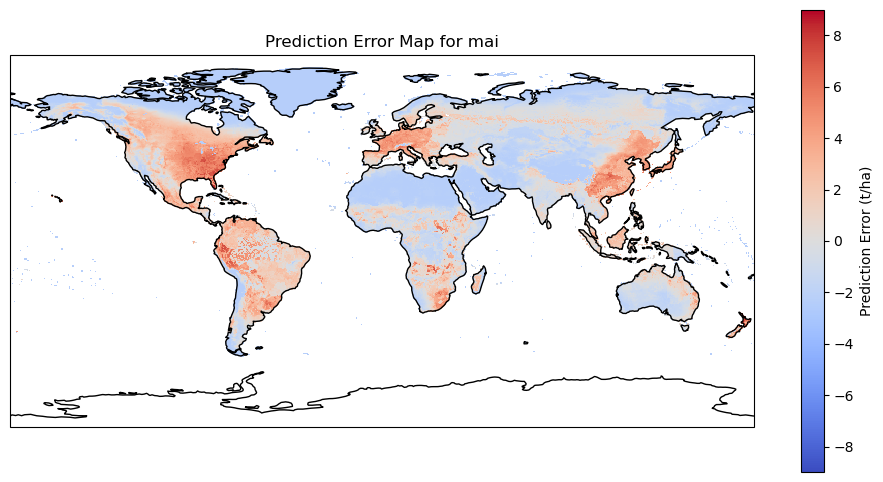

Error map for ri1...


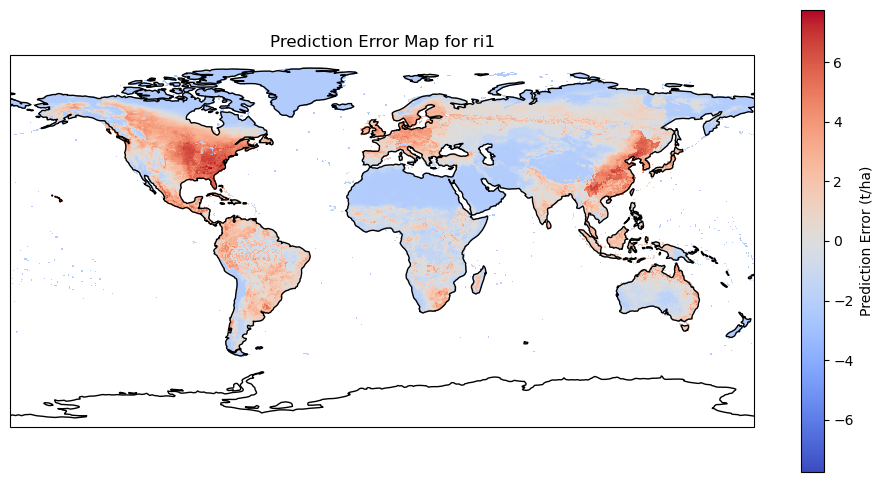

Error map for ri2...


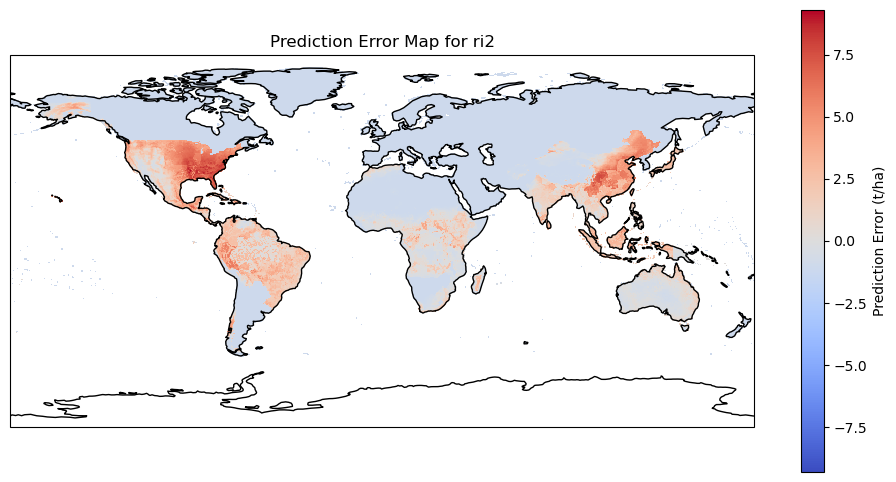

Error map for soy...


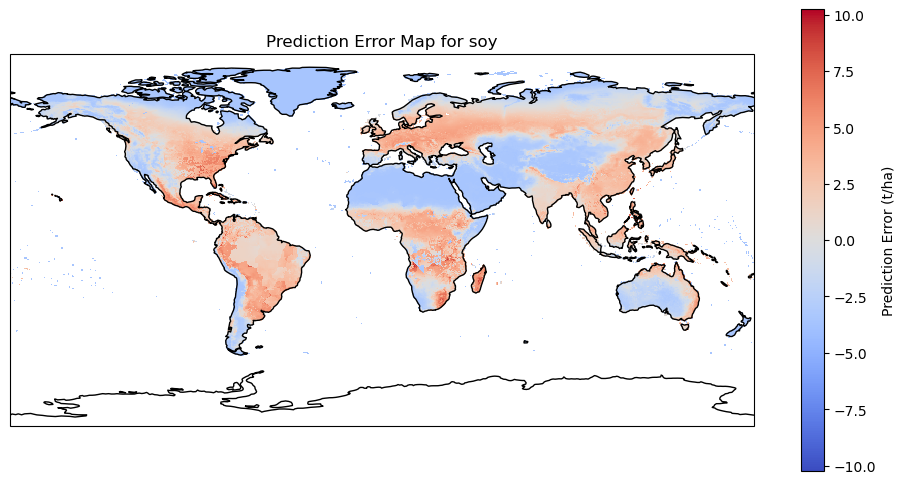

Error map for swh...


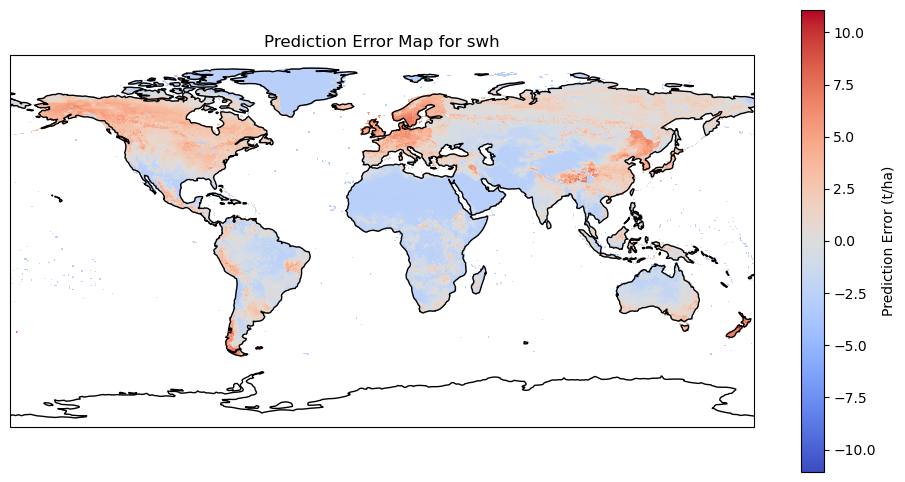

Error map for wwh...


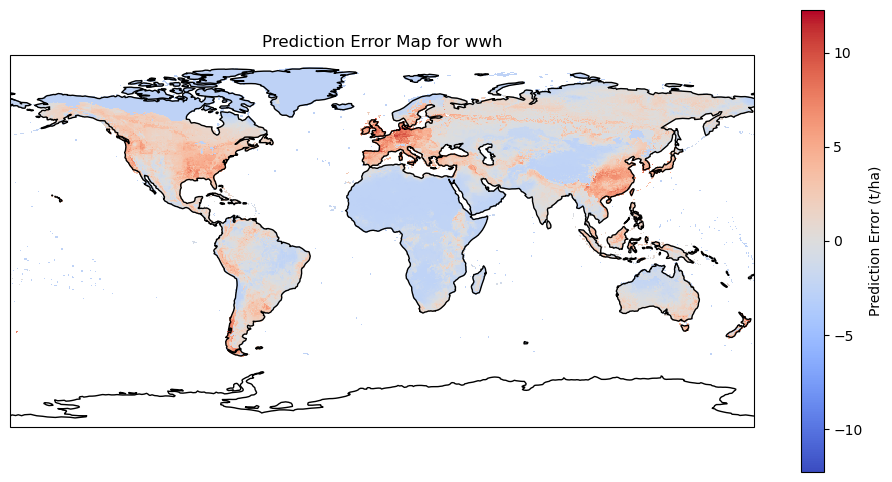

In [7]:
import cartopy.feature as cfeature

for crop in crop_variables:
    print(f"Error map for {crop}...")

    # Expand predictions to match (time, lat, lon) shape
    expanded_predictions = np.full(Ytest[crop].shape, predictions_dict[crop].flatten()[:, np.newaxis, np.newaxis])

    # Compute the mean error over time
    error_map = (Ytest[crop] - expanded_predictions).mean(dim="time")

    # Plot spatial error 
    plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    error_map.plot(cmap="coolwarm", transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Prediction Error (t/ha)"})

    ax.add_feature(cfeature.COASTLINE)
    ax.set_title(f"Prediction Error Map for {crop}")
    
    plt.show()

In [18]:
# Get summary statistics for crop yields
for crop in crop_variables:
    print(f"Statistics for {crop}:")
    
    # Ytrain statistics
    train_yield = get_Ytrain(train_files)[crop].mean(dim=["lat", "lon"]).values
    print(f"  Ytrain - Min: {train_yield.min()}, Max: {train_yield.max()}, Mean: {train_yield.mean()}")

    # Ytest statistics
    test_yield = Ytest[crop].mean(dim=["lat", "lon"]).values
    print(f"  Ytest - Min: {test_yield.min()}, Max: {test_yield.max()}, Mean: {test_yield.mean()}")
    print("-" * 50)

Statistics for mai:
  Ytrain - Min: 1.982361078262329, Max: 2.5594849586486816, Mean: 2.2758610248565674
  Ytest - Min: 2.209204912185669, Max: 2.5303125381469727, Mean: 2.3739986419677734
--------------------------------------------------
Statistics for ri1:
  Ytrain - Min: 1.28287672996521, Max: 2.7591733932495117, Mean: 1.9582843780517578
  Ytest - Min: 1.9681423902511597, Max: 2.6015241146087646, Mean: 2.2873449325561523
--------------------------------------------------
Statistics for ri2:
  Ytrain - Min: 0.6466788053512573, Max: 1.3433802127838135, Mean: 0.9277949333190918
  Ytest - Min: 0.908737063407898, Max: 1.2975398302078247, Mean: 1.0764390230178833
--------------------------------------------------
Statistics for soy:
  Ytrain - Min: 2.2942514419555664, Max: 4.222329139709473, Mean: 3.1464147567749023
  Ytest - Min: 3.0614795684814453, Max: 4.016366958618164, Mean: 3.550022840499878
--------------------------------------------------
Statistics for swh:
  Ytrain - Min: 1.91

In [ ]:
# RMSE values:

# Mai (Maize): 0.040
# Ri1 (Rice 1): 0.052
# Ri2 (Rice 2): 0.035
# Soy (Soybeans): 0.077
# Swh (Spring Wheat): 0.054
# Wwh (Winter Wheat): 0.048
# Compared to the mean yield values (~2-3 t/ha), RMSEs are relatively high.
# For example, in soy, the mean is ~3.5 t/ha, and RMSE is 0.077, which means:

# 0.077/ 3.5 = 2.2 error for soy

